## **TF-IDF Context-Length Analysis**

This notebook evaluates how the frozen TF-IDF logistic regression classifier responds to different amounts of recent retrieved context.

For each user-target pair, the model is evaluated using only the $k$ most recent retrieved context posts, with $k \in \{1,\ldots,7\}$. For examples with uniquely recovered timestamps, the retrieved posts are ordered from newest to oldest during preprocessing. Predictions under these reduced-context conditions are compared with predictions obtained from the full retrieved context.

The model is not retrained. All context-length conditions are evaluated on the same fixed subset of the human-annotated test set so that differences across $k$ reflect changes in available context rather than changes in test-set composition.

We cap the analysis at $k=7$ because requiring all ten potentially retrieved posts would reduce the common evaluation subset substantially: only 4.4% of the human-annotated examples contain ten retrieved posts, whereas 85.5% contain at least seven. Using $k \leq 7$ therefore provides a substantially broader fixed evaluation subset while still covering a wide range of context lengths.

### **1. Setup**

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

In [2]:
DATA_DIR = Path("../data/preprocessed")
MODEL_DIR = Path("../models/tfidf_logreg")
RESULTS_DIR = Path("../results/tfidf_context_length")

HUMAN_TEST_PATH = DATA_DIR / "human_test.parquet"
MODEL_PATH = MODEL_DIR / "model.joblib"

K_VALUES = list(range(1, 8))
K_MAX = max(K_VALUES)

### **2. Load the Human-Annotated Test Set and TF-IDF Model**

The analysis uses the held-out human-annotated test set and the TF-IDF logistic regression model trained previously on the LLM-labelled training split.


In [3]:
human_test = pd.read_parquet(HUMAN_TEST_PATH)
tfidf_logreg = joblib.load(MODEL_PATH)

print(f"Human test examples: {len(human_test):,}")
print(f"Columns: {human_test.columns.tolist()}")
print(f"Context-length conditions: {K_VALUES}")

Human test examples: 890
Columns: ['UserId', 'TargetEntity', 'StanceLabel', 'ContextPosts']
Context-length conditions: [1, 2, 3, 4, 5, 6, 7]


In [4]:
# Define the mapping between stance labels and numeric class IDs
LABEL2ID = {
    "Against": 0,
    "Favor": 1,
    "Neither": 2,
}

# Reverse mapping for converting model outputs back to stance labels
ID2LABEL = {
    value: key
    for key, value in LABEL2ID.items()
}

# Fixed label order used for evaluation tables and metrics
LABEL_ORDER = [
    "Against",
    "Favor",
    "Neither",
]

In [5]:
# Verify the class order used internally by the classifier
classifier = tfidf_logreg.named_steps["classifier"]

print(f"Classifier classes: {classifier.classes_.tolist()}")

Classifier classes: [0, 1, 2]


### **3. Define the Fixed Temporal Evaluation Subset**

A direct comparison across context lengths requires the same test examples to be used for every value of $k$. We therefore restrict the analysis to user-target pairs containing at least seven retrieved context posts.

Because this experiment explicitly relies on temporal ordering, examples containing context posts whose timestamps could not be uniquely recovered are excluded. The resulting fixed subset is used for all $k \in \{1,\ldots,7\}$ conditions and for the corresponding full-context reference condition.

Before defining the fixed evaluation subset, we audit whether each example contains enough retrieved posts for all context-length conditions and whether ambiguous timestamps prevent a reliable temporal ordering. These quantities are used only to determine eligibility for the analysis.

In [6]:
# Audit context length and timestamp quality for each test example
context_audit = pd.DataFrame({
    "num_context_posts": human_test["ContextPosts"].apply(len),
    "num_ambiguous_timestamps": human_test["ContextPosts"].apply(
        lambda posts: sum(
            bool(post["IsAmbiguous"])
            for post in posts
        )
    ),
})

# Report how many examples contain enough posts for the maximum context length
print(
    f"Examples with at least {K_MAX} posts: "
    f"{(context_audit['num_context_posts'] >= K_MAX).sum():,} "
    f"({(context_audit['num_context_posts'] >= K_MAX).mean():.1%})"
)

# Report how often potentially ambiguous timestamps occur
print(
    "Examples with ambiguous timestamps: "
    f"{(context_audit['num_ambiguous_timestamps'] > 0).sum():,} "
    f"({(context_audit['num_ambiguous_timestamps'] > 0).mean():.1%})"
)

Examples with at least 7 posts: 761 (85.5%)
Examples with ambiguous timestamps: 44 (4.9%)


In [7]:
# Report how many test examples contain the full set of 10 retrieved context posts
print(
    "Examples with all 10 retrieved posts: "
    f"{(context_audit['num_context_posts'] == 10).sum():,} "
    f"({(context_audit['num_context_posts'] == 10).mean():.1%})"
)

Examples with all 10 retrieved posts: 39 (4.4%)


In [8]:
# Select examples that support all evaluated context lengths and have an unambiguous temporal ordering
eligible_mask = (
    (context_audit["num_context_posts"] >= K_MAX)
    & (context_audit["num_ambiguous_timestamps"] == 0)
)

# Create one fixed subset used for all context-length evaluations
evaluation_data = human_test.loc[eligible_mask].copy().reset_index(drop=True)

# Report the size and coverage of the fixed evaluation subset
print(
    f"Fixed evaluation subset: "
    f"{len(evaluation_data):,} / {len(human_test):,} examples "
    f"({len(evaluation_data) / len(human_test):.1%})"
)

# Compare categorical distributions before and after subset selection
def compare_distribution(column):
    return pd.concat(
        {
            "Full human test (%)": (human_test[column].value_counts(normalize=True).mul(100)),
            "Fixed subset (%)": (evaluation_data[column].value_counts(normalize=True).mul(100))
        },
        axis=1,
    ).round(1)

# Check whether target proportions change after filtering
print("\nTarget distribution:")
display(compare_distribution("TargetEntity"))

print("\nStance distribution:")
display(compare_distribution("StanceLabel"))

# Show the context-length distribution within the fixed evaluation subset
evaluation_data["ContextPosts"].apply(len).value_counts().sort_index()

Fixed evaluation subset: 721 / 890 examples (81.0%)

Target distribution:


,Full human test (%),Fixed subset (%)
TargetEntity,,
Trump,50.0,48.4
Harris,50.0,51.6



Stance distribution:


,Full human test (%),Fixed subset (%)
StanceLabel,,
Against,49.4,49.4
Favor,26.4,26.4
Neither,24.2,24.3


ContextPosts
7     251
8     266
9     166
10     38
Name: count, dtype: int64

The fixed subset retains 721 of the 890 human-labelled examples (81.0%). Its target and overall stance distributions remain close to those of the complete human-annotated test set. All subsequent context-length conditions are evaluated on these same 721 examples. The resulting estimates therefore describe context-length sensitivity for examples with at least seven retrieved posts and an unambiguous temporal ordering.

In [9]:
# Compute the stance distribution separately within each target
def target_stance_distribution(data):
    return (
        pd.crosstab(
            data["TargetEntity"],
            data["StanceLabel"],
            normalize="index",
        )
        .reindex(columns=LABEL_ORDER)
        .mul(100)
        .round(1)
    )

# Compare target-specific stance distributions before and after filtering
print("\nTarget-specific stance distribution:")

display(
    pd.concat(
        {
            "Full human test (%)":target_stance_distribution(human_test),
            "Fixed subset (%)":target_stance_distribution(evaluation_data)
        },
        axis=1,
    )
)


Target-specific stance distribution:


Full human test (%)               Fixed subset (%)              
StanceLabel              Against Favor Neither          Against Favor Neither
TargetEntity                                                                 
Harris                      11.2  49.2    39.6             11.0  48.4    40.6
Trump                       87.6   3.6     8.8             90.3   2.9     6.9

The target-specific stance distributions also remain similar between the complete human-annotated test set and the fixed evaluation subset, indicating that the eligibility restriction does not substantially alter the target-specific class composition.

### **4. Construct the Context-Length Variants**

For each example, reduced-context variants are created by retaining the first $k$ posts from the chronologically ordered retrieved context. Since the posts are ordered from newest to oldest, each variant contains exactly the $k$ most recent retrieved posts. The target and gold stance label remain unchanged.

In [10]:
def keep_most_recent_posts(context_posts, k):
    return list(context_posts[:k])

In [11]:
# Create one evaluation variant for each context length 
context_variants = {}

for k in K_VALUES:

    variant = evaluation_data.copy()

    # Keep only the k most recent context posts for each example
    variant["ContextPosts"] = variant["ContextPosts"].apply(
        lambda posts, k=k: keep_most_recent_posts(
            posts,
            k,
        )
    )

    context_variants[k] = variant

### **5. Build Model Inputs**

The reduced contexts are converted to model inputs using the same input construction as during TF-IDF training. The supplied target precedes the retrieved context, with `TARGET_SEP` separating the target from the posts and `POST_SEP` separating individual posts. Keeping the input construction unchanged ensures that only the amount of available context varies across conditions.

In [12]:
# Concatenate the retained context posts using the same separator that was used when constructing the original TF-IDF model input
def build_context_text(context_posts):
    posts = [
        post["Content"]
        for post in context_posts
        if isinstance(post["Content"], str)
        and post["Content"].strip()
    ]

    return " POST_SEP ".join(posts)

# Reconstruct the complete classifier input from target and context
def build_model_input(row):
    context_text = build_context_text(
        row["ContextPosts"]
    )

    return (
        f"{row['TargetEntity']} TARGET_SEP "
        f"{context_text}"
    )

In [13]:
# Reconstruct the full-context model inputs for the fixed evaluation subset
full_texts = evaluation_data.apply(
    build_model_input,
    axis=1,
)

In [14]:
# Reconstruct the model inputs for each evaluated context length
context_texts = {
    k: variant.apply(
        build_model_input,
        axis=1,
    )
    for k, variant in context_variants.items()
}

### **6. Evaluate the Full-Context Reference**

The unchanged full retrieved context serves as the reference condition for the context-length analysis. For the eligible examples, this reference contains all available retrieved posts rather than truncating the context at $k=7$. Full-context length therefore varies between seven and ten retrieved posts; for examples containing exactly seven posts, the $k=7$ condition is identical to the full-context condition. To ensure a direct comparison, its performance is recomputed on the same fixed subset of 721 examples used for all reduced-context conditions.

In [15]:
# Extract the gold stance labels for the fixed evaluation subset
y_true = evaluation_data["StanceLabel"].to_numpy()

# Predict numeric class IDs using the full available context
full_pred_ids = tfidf_logreg.predict(full_texts)

# Obtain class probabilities for the same full-context inputs
full_probabilities = tfidf_logreg.predict_proba(full_texts)

# Convert numeric predictions back to the original stance labels
full_predictions = np.array([
    ID2LABEL[pred_id]
    for pred_id in full_pred_ids
])

In [16]:
# Compute Macro-F1 for the full-context reference condition
full_macro_f1 = f1_score(
    y_true,
    full_predictions,
    labels=LABEL_ORDER,
    average="macro"
)

print(
    f"Full-context Macro-F1 "
    f"({len(evaluation_data):,} examples): "
    f"{full_macro_f1:.4f}"
)

Full-context Macro-F1 (721 examples): 0.7363


### **7. Run Context-Length Predictions**

The frozen classifier is applied to each reduced-context condition without retraining. For every value of $k$, both the predicted stance labels and class probabilities are retained for comparison with the full-context reference.

In [17]:
# Store predictions and class probabilities for each context length
context_predictions = {}
context_probabilities = {}

for k in K_VALUES:

    # Predict numeric class IDs for the current context-length variant
    pred_ids = tfidf_logreg.predict(
        context_texts[k]
    )

    # Obtain class probabilities for the same inputs
    probabilities = tfidf_logreg.predict_proba(
        context_texts[k]
    )

    # Convert numeric predictions back to stance labels
    predictions = np.array([
        ID2LABEL[pred_id]
        for pred_id in pred_ids
    ])

    context_predictions[k] = predictions
    context_probabilities[k] = probabilities

### **8. Evaluate Context-Length Effects**

Each reduced-context condition is compared with the full-context reference on the same examples. We report macro-F1, the change in macro-F1 relative to full context, the proportion of predictions that differ from the full-context prediction, and probability-based measures of prediction change.

The full-context predicted class is used as the reference when measuring class-probability change. Negative values therefore indicate that reducing the available context lowers the model's probability for the class selected under full context.

Mean absolute probability change denotes the absolute difference between the reduced- and full-context probability vectors, averaged across examples and stance classes.

In [18]:
# Convert the full-context predicted labels to their numeric class indices
full_pred_indices = np.array([
    LABEL2ID[label]
    for label in full_predictions
])

# Create row indices for selecting one class probability per example
row_indices = np.arange(len(evaluation_data))

# Extract the probability assigned to each example's predicted class
full_predicted_class_prob = full_probabilities[row_indices, full_pred_indices]

In [19]:
context_length_rows = []

for k in K_VALUES:

    predictions = context_predictions[k]
    probabilities = context_probabilities[k]

    # Compute Macro-F1 for the current context length
    macro_f1 = f1_score(
        y_true,
        predictions,
        labels=LABEL_ORDER,
        average="macro",
    )

    # Measure the performance change relative to full context
    delta_macro_f1 = (macro_f1 - full_macro_f1)

    # Measure how often the predicted label changes relative to full context
    flip_rate = np.mean(predictions != full_predictions)

    # Extract the probability assigned to the original full-context class
    reduced_full_class_prob = probabilities[row_indices, full_pred_indices]

    # Measure how support for the full-context prediction changes
    full_class_probability_change = (reduced_full_class_prob - full_predicted_class_prob)

    # Measure the average absolute change across all class probabilities
    mean_absolute_probability_change = np.abs(probabilities - full_probabilities).mean()

    # Store all metrics for the current context length
    context_length_rows.append(
        {
            "k": k,
            "n": len(evaluation_data),
            "macro_f1": macro_f1,
            "delta_macro_f1": delta_macro_f1,
            "flip_rate_vs_full": flip_rate,
            "mean_full_class_probability_change":
                full_class_probability_change.mean(),
            "mean_absolute_probability_change":
                mean_absolute_probability_change,
        }
    )

context_length_results = pd.DataFrame(
    context_length_rows
)

# Add the full-context Macro-F1 as a constant reference column
context_length_results["full_context_macro_f1"] = full_macro_f1

context_length_results.round(4)

,k,n,macro_f1,delta_macro_f1,flip_rate_vs_full,mean_full_class_probability_change,mean_absolute_probability_change,full_context_macro_f1
0,1,721,0.5619,-0.1744,0.2913,-0.1441,0.1770,0.7363
1,2,721,0.6096,-0.1267,0.2483,-0.1279,0.1485,0.7363
2,3,721,0.6413,-0.0950,0.1914,-0.0987,0.1177,0.7363
3,4,721,0.6723,-0.0640,0.1470,-0.0719,0.0900,0.7363
4,5,721,0.6817,-0.0546,0.1151,-0.0497,0.0694,0.7363
5,6,721,0.6998,-0.0365,0.0915,-0.0305,0.0490,0.7363
6,7,721,0.7217,-0.0146,0.0458,-0.0115,0.0249,0.7363


### **9. Target-Specific Context-Length Effects**

Because stance is defined relative to a specific political target, we additionally examine whether sensitivity to context length differs between Harris and Trump examples. All target-specific results use the same fixed evaluation subset and compare each reduced-context condition with the corresponding full-context predictions for that target.

In [20]:
# Collect context-length metrics separately for each target
target_specific_rows = []

for target in sorted(evaluation_data["TargetEntity"].unique()):

    # Select all examples belonging to the current target
    target_mask = (evaluation_data["TargetEntity"].to_numpy() == target)

    target_y_true = y_true[target_mask]
    target_full_predictions = (full_predictions[target_mask])
    target_full_probabilities = (full_probabilities[target_mask])
    target_full_pred_indices = (full_pred_indices[target_mask])

    # Create row indices for probability lookup within this target subset
    target_row_indices = np.arange(target_mask.sum())

    # Extract the probability assigned to each full-context predicted class
    target_full_predicted_class_prob = (target_full_probabilities[target_row_indices, target_full_pred_indices])

    # Compute the full-context Macro-F1 reference for this target
    target_full_macro_f1 = f1_score(
        target_y_true,
        target_full_predictions,
        labels=LABEL_ORDER,
        average="macro",
    )

    for k in K_VALUES:

        # Select predictions and probabilities for the current context length
        target_predictions = (context_predictions[k][target_mask])
        target_probabilities = (context_probabilities[k][target_mask])

        # Compute Macro-F1 for the current target and context length
        macro_f1 = f1_score(
            target_y_true,
            target_predictions,
            labels=LABEL_ORDER,
            average="macro",
        )

        # Extract probabilities assigned to the original full-context classes
        reduced_full_class_prob = (target_probabilities[target_row_indices, target_full_pred_indices])

        target_specific_rows.append(
            {
                "target": target,
                "k": k,
                "n": target_mask.sum(),
                "macro_f1": macro_f1,
                "delta_macro_f1": (macro_f1 - target_full_macro_f1),
                "flip_rate_vs_full": np.mean(target_predictions != target_full_predictions),
                "mean_full_class_probability_change": (reduced_full_class_prob - target_full_predicted_class_prob).mean(),
                "mean_absolute_probability_change": np.abs(target_probabilities - target_full_probabilities).mean(),
                "full_context_macro_f1": target_full_macro_f1
            }
        )

target_specific_results = pd.DataFrame(target_specific_rows)

In [21]:
target_specific_results[
    [
        "target",
        "k",
        "n",
        "macro_f1",
        "full_context_macro_f1",
        "delta_macro_f1",
        "flip_rate_vs_full",
    ]
].round(4)

,target,k,n,macro_f1,full_context_macro_f1,delta_macro_f1,flip_rate_vs_full
0,Harris,1,372,0.3045,0.5377,-0.2332,0.4624
1,Harris,2,372,0.3829,0.5377,-0.1548,0.3844
2,Harris,3,372,0.4364,0.5377,-0.1012,0.3172
3,Harris,4,372,0.4602,0.5377,-0.0775,0.2608
4,Harris,5,372,0.4785,0.5377,-0.0592,0.2043
5,Harris,6,372,0.5237,0.5377,-0.0140,0.1532
6,Harris,7,372,0.5267,0.5377,-0.0110,0.0806
7,Trump,1,349,0.4073,0.4185,-0.0112,0.1089
8,Trump,2,349,0.4177,0.4185,-0.0008,0.1032
9,Trump,3,349,0.3747,0.4185,-0.0438,0.0573


Because the preceding dataset analysis showed a strong association between target and stance label, absolute target-specific Macro-F1 values are not interpreted as directly comparable measures of target difficulty. The main focus is therefore on within-target changes relative to the corresponding full-context predictions. Consequently, the Harris-Trump comparison concerns sensitivity to context reduction, not absolute classification difficulty. The overall Macro-F1 is computed on all evaluation examples jointly, whereas the target-specific scores are computed separately for Harris and Trump. Therefore, the overall score cannot be obtained by averaging the two target-specific Macro-F1 values.

### **10. Visualize Context-Length Effects**

The following figures summarize how predictive performance and decision stability change as progressively more recent retrieved posts are included. The full-context performance serves as the reference for the overall Macro-F1 comparison, while target-specific effects are expressed relative to each target's own full-context predictions.

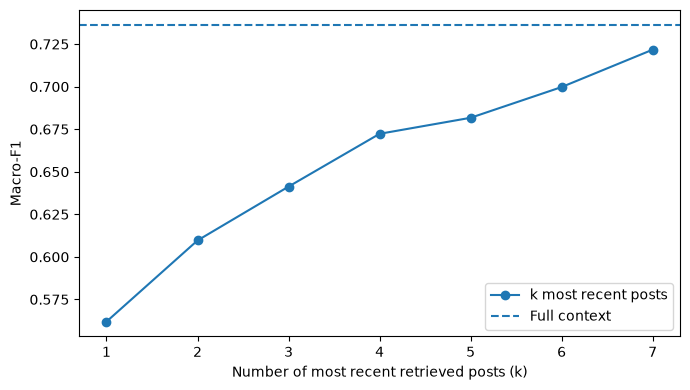

In [22]:
# Plot Macro-F1 as a function of the number of most recent context posts
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    context_length_results["k"],
    context_length_results["macro_f1"],
    marker="o",
    label="k most recent posts"
)

# Add full-context performance as a reference
ax.axhline(
    full_macro_f1,
    linestyle="--",
    label="Full context"
)

ax.set_xlabel("Number of most recent retrieved posts (k)")
ax.set_ylabel("Macro-F1")
ax.set_xticks(K_VALUES)
ax.legend()

plt.tight_layout()
plt.show()

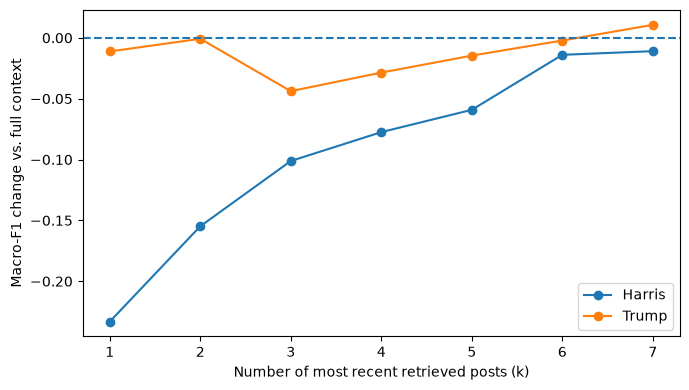

In [23]:
# Plot the target-specific change in Macro-F1 relative to full context
fig, ax = plt.subplots(figsize=(7, 4))

for target in sorted(
    target_specific_results["target"].unique()
):
    target_data = target_specific_results[
        target_specific_results["target"] == target
    ]

    ax.plot(
        target_data["k"],
        target_data["delta_macro_f1"],
        marker="o",
        label=target
    )

ax.axhline(0, linestyle="--")

ax.set_xlabel("Number of most recent retrieved posts (k)")
ax.set_ylabel("Macro-F1 change vs. full context")
ax.set_xticks(K_VALUES)
ax.legend()

plt.tight_layout()
plt.show()

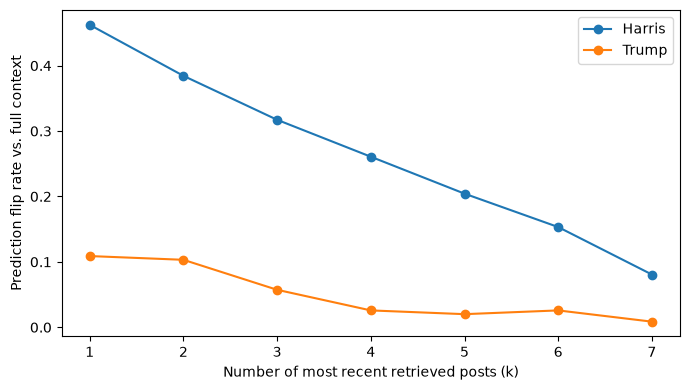

In [24]:
# Plot target-specific prediction flip rates relative to full context
fig, ax = plt.subplots(figsize=(7, 4))

for target in sorted(
    target_specific_results["target"].unique()
):
    target_data = target_specific_results[target_specific_results["target"] == target]

    ax.plot(
        target_data["k"],
        target_data["flip_rate_vs_full"],
        marker="o",
        label=target
    )

ax.set_xlabel("Number of most recent retrieved posts (k)")
ax.set_ylabel("Prediction flip rate vs. full context")
ax.set_xticks(K_VALUES)
ax.legend()

plt.tight_layout()
plt.show()

### **11. Interpretation**

The overall results show a consistent increase in Macro-F1 as additional recent retrieved posts are included. Performance rises from 0.562 with only the most recent post to 0.722 with the seven most recent posts, approaching the full-context Macro-F1 of 0.736. Prediction differences relative to full context decrease correspondingly from 29.1% at $k=1$ to 4.6% at $k=7$. The particularly small difference at $k=7$ is partly expected because this condition is identical to full context for the 251 of 721 examples that contain exactly seven retrieved posts.

The target-specific analysis reveals a pronounced asymmetry. Harris predictions are substantially more sensitive to reduced context: with only the most recent post, 46.2% of predictions differ from the corresponding full-context predictions and Macro-F1 is 0.233 lower than under full context. For Trump, the corresponding flip rate is only 10.9% and the Macro-F1 difference is 0.011. As additional posts are included, predictions for both targets generally converge toward their full-context counterparts.

For TF-IDF, these results should be interpreted as sensitivity to the amount of recent retrieved lexical evidence rather than sensitivity to temporal order itself, since the TF-IDF representation does not explicitly model post order.

### **12. Save Evaluation Results**

Save the overall and target-specific context-length results, together with the fixed evaluation subset used throughout the analysis. The saved subset identifiers allow the corresponding RoBERTa analysis to use exactly the same user-target examples.

In [25]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

context_length_results.to_csv(RESULTS_DIR / "overall_context_length_results.csv", index=False)

target_specific_results.to_csv(RESULTS_DIR / "target_specific_context_length_results.csv", index=False)

evaluation_data[["UserId", "TargetEntity", "StanceLabel"]].to_csv(RESULTS_DIR / "evaluation_subset.csv", index=False)